## Modeling TFT for Early Forecasts using only Temporal Data

### Previous Step: Feature Engineering Design and EDA

### Next Step: Transform Results into Optimal Truck Calculation

---

##### TODO:

- `Apply Cyclical Encoding to temporal features`
- `Build long-format dataset ready for TFT`
- `Select a training and testing set`
- `Export train/test CSVs for external training`
- `Evaluate with metrics and graph testing results`
- `Export model into .pkl file`

---
### 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Paths
PROCESSED_DIR = Path('../data/processed')
MODEL_READY_CSV = PROCESSED_DIR / 'remissions_model_ready.csv'

# Temporal split date: everything BEFORE this date = train, ON/AFTER = test
# You can adjust this. With data from 2020-02 to 2026-04, 2025-01-01 gives ~5 years train, ~1.3 years test.
TRAIN_CUTOFF_DATE = '2025-01-01'

print("Configuration ready.")
print(f"Train cutoff: {TRAIN_CUTOFF_DATE}")

Configuration ready.
Train cutoff: 2025-01-01


---
### 2. Load Model-Ready Data

In [2]:
df = pd.read_csv(MODEL_READY_CSV)

# Parse hour_bucket as datetime (it is the true timestamp for each row)
df['hour_bucket'] = pd.to_datetime(df['hour_bucket'])

# TFT requires group_ids to be categorical/string, not numeric
df['ship_plant_code'] = df['ship_plant_code'].astype(str)

# Extract day of month from hour_bucket
df['day_of_month'] = df['hour_bucket'].dt.day

print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Plants: {sorted(df['ship_plant_code'].unique())}")
print(f"Date range: {df['hour_bucket'].min()} to {df['hour_bucket'].max()}")
print("\nColumns:", df.columns.tolist())

Loaded: 93,037 rows x 27 columns
Plants: ['510', '511', '512', '514', '515', '710']
Date range: 2020-02-26 07:00:00 to 2026-04-24 10:00:00

Columns: ['time_idx', 'ship_plant_code', 'hour_bucket', 'remission_count', 'volume_m3', 'hour', 'day_of_week', 'month', 'volume_m3_lag_24h', 'volume_m3_lag_48h', 'volume_m3_lag_1w', 'remission_count_lag_24h', 'remission_count_lag_48h', 'remission_count_lag_1w', 'volume_m3_roll_mean_24h', 'volume_m3_roll_mean_48h', 'volume_m3_roll_mean_1w', 'volume_m3_roll_std_24h', 'volume_m3_roll_std_48h', 'volume_m3_roll_std_1w', 'remission_count_roll_mean_24h', 'remission_count_roll_mean_48h', 'remission_count_roll_mean_1w', 'remission_count_roll_std_24h', 'remission_count_roll_std_48h', 'remission_count_roll_std_1w', 'day_of_month']


---
### 3. Cyclical Encoding of Temporal Features

Cyclical (sine/cosine) encoding tells the model that **hour 23 is close to hour 0**, and **December is close to January**. Without it, the model sees these as far apart.

We encode:
- `month` (1–12)
- `day_of_month` (1–31)
- `day_of_week` (0–6)
- `hour` (0–23)

In [3]:
def cyclical_encode(series, period, sin_col, cos_col, df_in=None):
    """
    Add sine and cosine encoding for a cyclical feature.
    
    series : pandas Series (0-indexed or 1-indexed values)
    period : max value + 1 (e.g., 24 for hours 0-23, 12 for months 1-12)
    """
    target = df_in if df_in is not None else df
    target[sin_col] = np.sin(2 * np.pi * series / period)
    target[cos_col] = np.cos(2 * np.pi * series / period)
    return target

# Apply encodings
df = cyclical_encode(df['month'],       period=12, sin_col='month_sin',       cos_col='month_cos',       df_in=df)
df = cyclical_encode(df['day_of_month'], period=31, sin_col='day_month_sin',   cos_col='day_month_cos',   df_in=df)
df = cyclical_encode(df['day_of_week'],  period=7,  sin_col='day_week_sin',    cos_col='day_week_cos',    df_in=df)
df = cyclical_encode(df['hour'],         period=24, sin_col='hour_sin',        cos_col='hour_cos',        df_in=df)

cyclical_cols = ['month_sin', 'month_cos', 'day_month_sin', 'day_month_cos',
                 'day_week_sin', 'day_week_cos', 'hour_sin', 'hour_cos']

print("Cyclical columns created:")
for c in cyclical_cols:
    print(f"  {c}: min={df[c].min():.4f}, max={df[c].max():.4f}")

Cyclical columns created:
  month_sin: min=-1.0000, max=1.0000
  month_cos: min=-1.0000, max=1.0000
  day_month_sin: min=-0.9987, max=0.9987
  day_month_cos: min=-0.9949, max=1.0000
  day_week_sin: min=-0.9749, max=0.9749
  day_week_cos: min=-0.9010, max=1.0000
  hour_sin: min=-1.0000, max=1.0000
  hour_cos: min=-1.0000, max=1.0000


---
### 4. Quick Visual Verification (Optional)

Plot the cyclical pairs to confirm they trace a circle (e.g., hour 0 ≈ hour 23).

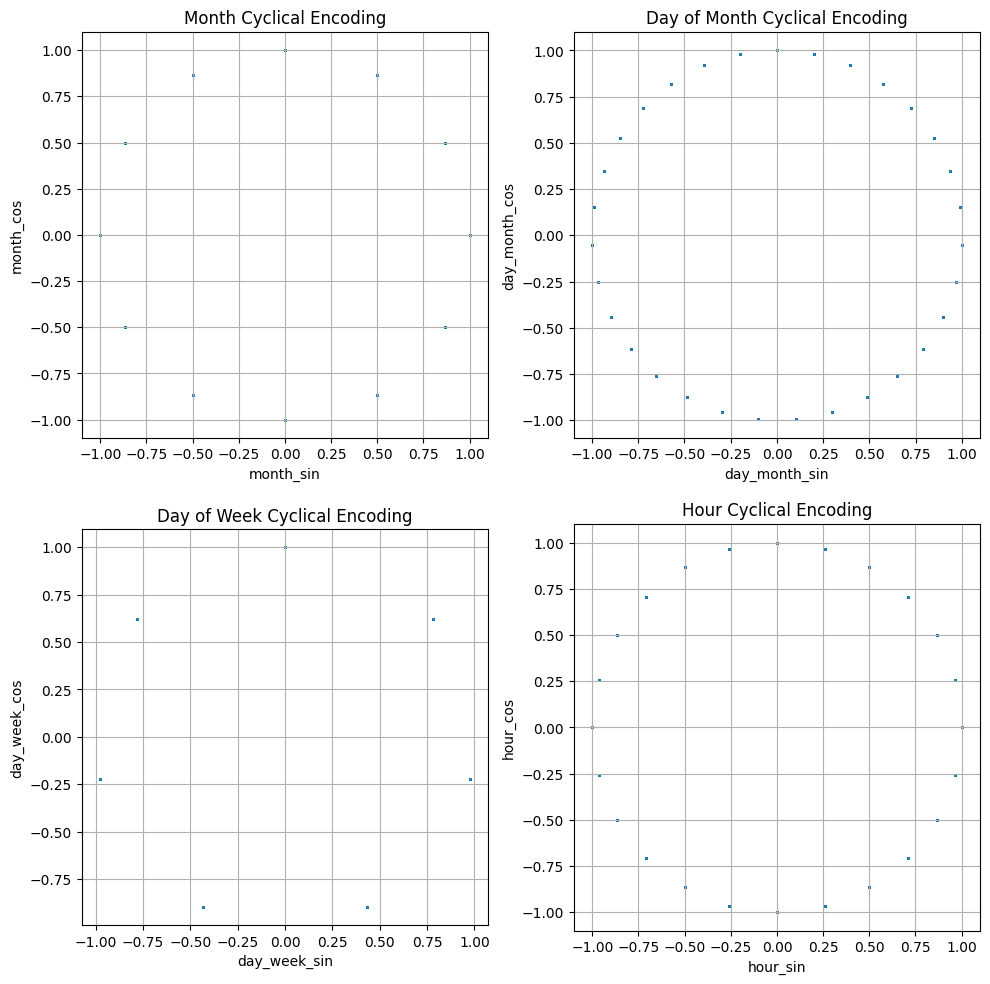

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
pairs = [
    ('month_sin', 'month_cos', 'Month'),
    ('day_month_sin', 'day_month_cos', 'Day of Month'),
    ('day_week_sin', 'day_week_cos', 'Day of Week'),
    ('hour_sin', 'hour_cos', 'Hour')
]

for ax, (sin_c, cos_c, title) in zip(axes.flat, pairs):
    ax.scatter(df[sin_c], df[cos_c], s=1, alpha=0.3)
    ax.set_xlabel(sin_c)
    ax.set_ylabel(cos_c)
    ax.set_title(f'{title} Cyclical Encoding')
    ax.set_aspect('equal')
    ax.grid(True)

plt.tight_layout()
plt.show()

---
### 5. Temporal Train / Test Split

For time-series forecasting we **must NOT shuffle** or use a random split. We cut by date so the model is trained on the past and tested on the future.

**Important TFT requirement:** Each time series (plant) in the test set must have enough historical rows before the cutoff to fill the encoder. We'll verify this after splitting.

In [5]:
cutoff = pd.Timestamp(TRAIN_CUTOFF_DATE)

train_df = df[df['hour_bucket'] < cutoff].copy()
test_df  = df[df['hour_bucket'] >= cutoff].copy()

print(f"TRAIN:  {len(train_df):,} rows | {train_df['hour_bucket'].min()} to {train_df['hour_bucket'].max()}")
print(f"TEST:   {len(test_df):,} rows  | {test_df['hour_bucket'].min()} to {test_df['hour_bucket'].max()}")
print()

# Verify every plant has data in both splits
train_plants = set(train_df['ship_plant_code'].unique())
test_plants  = set(test_df['ship_plant_code'].unique())
print("Plants in train:", sorted(train_plants))
print("Plants in test: ", sorted(test_plants))

# Rows per plant in each split
print("\nRows per plant:")
summary = pd.merge(
    train_df.groupby('ship_plant_code').size().rename('train_rows'),
    test_df.groupby('ship_plant_code').size().rename('test_rows'),
    left_index=True, right_index=True, how='outer'
).fillna(0).astype(int)
print(summary)

TRAIN:  70,714 rows | 2020-02-26 07:00:00 to 2024-12-31 11:00:00
TEST:   22,323 rows  | 2025-01-01 06:00:00 to 2026-04-24 10:00:00

Plants in train: ['510', '511', '512', '514', '515', '710']
Plants in test:  ['510', '511', '512', '514', '515', '710']

Rows per plant:
                 train_rows  test_rows
ship_plant_code                       
510                   13301       3618
511                   13088       3869
512                   13161       3855
514                    6330       3672
515                   12887       3927
710                   11947       3382


---
### 6. Export Train / Test CSVs for External Training

These CSVs are what you copy to the other computer and point `training.py` at.

In [6]:
train_path = PROCESSED_DIR / 'train_tft.csv'
test_path  = PROCESSED_DIR / 'test_tft.csv'

train_df.to_csv(train_path, index=False)
test_df.to_csv(test_path, index=False)

print(f"Saved train → {train_path}")
print(f"Saved test  → {test_path}")
print(f"\nFile sizes:")
print(f"  train_tft.csv: {train_path.stat().st_size / 1_048_576:.2f} MB")
print(f"  test_tft.csv:  {test_path.stat().st_size / 1_048_576:.2f} MB")

Saved train → ..\data\processed\train_tft.csv
Saved test  → ..\data\processed\test_tft.csv

File sizes:
  train_tft.csv: 28.40 MB
  test_tft.csv:  9.05 MB


---
### 7. (Optional) Build TFT Dataset Locally & Sanity Check

If you want to verify the dataset works before moving to the other machine, run this cell. It creates a `TimeSeriesDataSet` with the exact same settings `training.py` will use.

> **Dependencies:** `torch`, `pytorch-forecasting`, `pytorch-lightning`

In [7]:
#Uncomment and run only if you have pytorch-forecasting installed locally
from pytorch_forecasting import TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer

MAX_ENCODER_LENGTH = 168      # 1 week of history
MAX_PREDICTION_LENGTH = 24    # Predict next 24 hours

known_reals = [
    'month_sin', 'month_cos',
    'day_month_sin', 'day_month_cos',
    'day_week_sin', 'day_week_cos',
    'hour_sin', 'hour_cos'
]

unknown_reals = [
    'volume_m3_lag_24h', 'volume_m3_lag_48h', 'volume_m3_lag_1w',
    'remission_count_lag_24h', 'remission_count_lag_48h', 'remission_count_lag_1w',
    'volume_m3_roll_mean_24h', 'volume_m3_roll_mean_48h', 'volume_m3_roll_mean_1w',
    'volume_m3_roll_std_24h', 'volume_m3_roll_std_48h', 'volume_m3_roll_std_1w',
    'remission_count_roll_mean_24h', 'remission_count_roll_mean_48h', 'remission_count_roll_mean_1w',
    'remission_count_roll_std_24h', 'remission_count_roll_std_48h', 'remission_count_roll_std_1w'
]

training = TimeSeriesDataSet(
    train_df,
    time_idx="time_idx",
    target="volume_m3",
    group_ids=["ship_plant_code"],
    max_encoder_length=MAX_ENCODER_LENGTH,
    max_prediction_length=MAX_PREDICTION_LENGTH,
    static_categoricals=["ship_plant_code"],
    time_varying_known_reals=known_reals,
    time_varying_unknown_reals=unknown_reals,
    target_normalizer=GroupNormalizer(groups=["ship_plant_code"]),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

print(f"TFT dataset created successfully!")
print(f"  Number of samples (batches): {len(training)}")
print(f"  Known reals: {len(known_reals)}")
print(f"  Unknown reals: {len(unknown_reals)}")

TFT dataset created successfully!
  Number of samples (batches): 69568
  Known reals: 8
  Unknown reals: 18


---
### Next Steps

1. **Copy the exported CSVs** (`train_tft.csv`, `test_tft.csv`) to the training computer.
2. **Install dependencies** on that machine:
   ```bash
   pip install torch pytorch-forecasting pytorch-lightning pandas numpy matplotlib
   ```
3. **Run `training.py`** (located at `Modulo_Alberto/training.py`).
4. **Bring back** the saved model checkpoint and prediction CSVs.